# Cluster Summary — Papers

Cluster-level summaries and figures for the papers topic model.

This notebook computes citation/year-normalized metrics per topic and exports:
- `assets/reports/cluster_summary.tsv`

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import zscore

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)

ASSETS = os.path.join('..', 'assets')
MODELS = os.path.join(ASSETS, 'topic_models')
REPORTS = os.path.join(ASSETS, 'reports')
os.makedirs(REPORTS, exist_ok=True)

In [2]:
# Load papers dataset
papers = pd.read_csv(os.path.join(ASSETS, 'synbio_openalex.txt'), sep='\t')

# Load topic assignments and topic names
doc_topics = pd.read_csv(os.path.join(MODELS, 'papers_doc_topics.txt'), sep='\t')
topic_names = pd.read_csv(os.path.join(MODELS, 'papers_topic_names.txt'), sep='\t')

# Merge topics into papers
papers = papers.merge(doc_topics, on='id', how='left')
papers = papers.merge(topic_names[['topic', 'global_name']], on='topic', how='left')

# Basic cleaning
papers['cited_by_count'] = pd.to_numeric(papers['cited_by_count'], errors='coerce').fillna(0).astype(int)
papers['publication_year'] = pd.to_numeric(papers['publication_year'], errors='coerce')

print(f"Papers: {len(papers):,}")
print(f"Topics: {papers['topic'].nunique()} (incl. outlier -1)")
papers.head(3)

Papers: 24,202
Topics: 264 (incl. outlier -1)


,id,doi,title,publication_year,language,type,source_id,source_name,authors,institutions,countries,cited_by_count,abstract,concepts,referenced_works,topic,global_name
0,https://openalex.org/W2072812562,https://doi.org/10.1073/pnas.82.20.6955,Rapid determination of 16S ribosomal RNA seque...,1985,en,article,https://openalex.org/S125754415,Proceedings of the National Academy of Sciences,David Lane; B Pace; G J Olsen; David A. Stahl;...,Indiana University Bloomington; Jewish Hospital,USA,3046,Although the applicability of small subunit ri...,16S ribosomal RNA; Ribosomal RNA; Biology; Phy...,0.0,167,Ribosomal RNA and Gene Engineering
1,https://openalex.org/W2091309425,https://doi.org/10.1093/nar/17.19.7843,Isolation and direct complete nucleotide deter...,1989,en,article,https://openalex.org/S134668137,Nucleic Acids Research,Ulrike Edwards; T. Rogall; Helmut Blöcker; Mon...,Medizinische Hochschule Hannover,Germany,2706,Using a set of synthetic oligonucleotides homo...,Biology; Gene; Nucleic acid sequence; Genetics...,0.0,167,Ribosomal RNA and Gene Engineering
2,https://openalex.org/W2037457710,https://doi.org/10.1093/nar/9.2.309,A system for shotgun DNA sequencing,1981,en,article,https://openalex.org/S134668137,Nucleic Acids Research,Joachim Messing; Roberto Crea; Peter H. Seeburg,Max Planck Institute for Medical Research; Max...,Germany; USA,2650,A multipurpose cloning site has been introduce...,Biology; Restriction enzyme; Molecular biology...,0.0,44,Genetic System Engineering


## Yearly-normalized citations

Three normalization approaches applied per publication year:
- **Z-norm**: z-score of raw citations within each year
- **Log**: z-score of log(1 + citations) within each year
- **Rank**: percentile rank of citations within each year (0-1)

In [3]:
# Log transform (applied before z-scoring)
papers['log_citations'] = np.log1p(papers['cited_by_count'])

# Z-norm: z-score of raw citations per year
papers['TC_znorm'] = papers.groupby('publication_year')['cited_by_count'].transform(
    lambda x: zscore(x, ddof=1) if len(x) > 1 else 0.0
)

# Log z-norm: z-score of log(1+citations) per year
papers['TC_log'] = papers.groupby('publication_year')['log_citations'].transform(
    lambda x: zscore(x, ddof=1) if len(x) > 1 else 0.0
)

# Rank: percentile rank per year (0 = least cited, 1 = most cited)
papers['TC_rank'] = papers.groupby('publication_year')['cited_by_count'].transform(
    lambda x: x.rank(pct=True)
)

papers[['id', 'publication_year', 'cited_by_count', 'TC_znorm', 'TC_log', 'TC_rank']].describe().round(3)

,publication_year,cited_by_count,TC_znorm,TC_log,TC_rank
count,24202.000,24202.000,24200.000,24200.000,24202.000
mean,2011.849,31.548,0.000,0.000,0.502
std,12.829,88.212,0.999,0.999,0.285
min,1950.000,0.000,-0.961,-2.288,0.036
25%,2007.000,1.000,-0.447,-0.797,0.257
50%,2016.000,8.000,-0.286,0.050,0.500
75%,2021.000,31.000,0.062,0.759,0.749
max,2025.000,3046.000,20.989,3.888,1.000


## Cluster-level summary

Average citations and normalized metrics per topic, plus recency measures:
- **avg_year**: plain average publication year
- **price_index**: fraction of papers from the last 5 years
- **avg_year_rank**: average percentile-rank of publication year across the full corpus

In [4]:
# Exclude outlier topic -1
papers_valid = papers[papers['topic'] >= 0].copy()

# Price Index: % of papers from the last 5 years
max_year = int(papers_valid['publication_year'].max())
papers_valid['is_recent'] = (papers_valid['publication_year'] >= max_year - 4).astype(int)

# Year-rank recency
papers_valid['year_rank'] = papers_valid['publication_year'].rank(pct=True)

cluster_summary = papers_valid.groupby('topic').agg(
    n_papers=('id', 'size'),
    avg_citations=('cited_by_count', 'mean'),
    avg_TC_znorm=('TC_znorm', 'mean'),
    avg_TC_log=('TC_log', 'mean'),
    avg_TC_rank=('TC_rank', 'mean'),
    avg_year=('publication_year', 'mean'),
    price_index=('is_recent', 'mean'),
    avg_year_rank=('year_rank', 'mean'),
).reset_index()

cluster_summary = cluster_summary.merge(
    topic_names[['topic', 'global_name']], on='topic', how='left'
)

cluster_summary_out = os.path.join(REPORTS, 'cluster_summary.tsv')
cluster_summary.to_csv(cluster_summary_out, sep='\t', index=False)

print(f"Clusters: {len(cluster_summary)}")
print(f"Price Index window: {max_year-4}-{max_year}")
print(f"Saved: {cluster_summary_out}")
cluster_summary.sort_values('avg_TC_log', ascending=False).head(10)

Clusters: 263
Price Index window: 2021-2025
Saved: ../assets/reports/cluster_summary.tsv


,topic,n_papers,avg_citations,avg_TC_znorm,avg_TC_log,avg_TC_rank,avg_year,price_index,avg_year_rank,global_name
200,200,27,36.555556,1.264680,0.961653,0.750313,2022.814815,0.777778,0.837115,AI in Synthetic Biology
259,259,20,68.650000,0.987758,0.839832,0.748923,2019.600000,0.550000,0.704932,CRISPR in Yeast Synthetic Biology
214,214,25,144.600000,0.859137,0.828478,0.746180,1999.720000,0.080000,0.229877,Synthetic Transcription in Mammalian Cells
169,169,32,80.031250,0.934869,0.807185,0.742634,2021.343750,0.687500,0.760882,CRISPR in Synthetic Biology
33,33,99,32.919192,0.873029,0.729787,0.693130,2021.545455,0.808081,0.816286,Synthetic Cell Compartments
152,152,35,60.114286,0.550397,0.700787,0.708753,2017.942857,0.285714,0.604813,Bacterial Microcompartments and Surface Layers
205,205,26,74.884615,0.443064,0.683426,0.689369,2012.846154,0.115385,0.436618,Biosensing Technologies in Synthetic Biology
201,201,27,27.148148,0.363143,0.668548,0.700103,2020.259259,0.555556,0.721988,Microalgal Synthetic Biology
148,148,36,73.527778,0.656106,0.664517,0.672334,2018.388889,0.388889,0.634371,Plant Synthetic Biology and Modular Engineering
192,192,28,87.857143,0.551720,0.663646,0.695716,2007.071429,0.000000,0.301362,DNA Charge Transfer Mechanisms


### Impact vs Recency scatterplot
Each dot is a topic. X = average publication year, Y = average log-normalized citations, size proportional to number of papers.

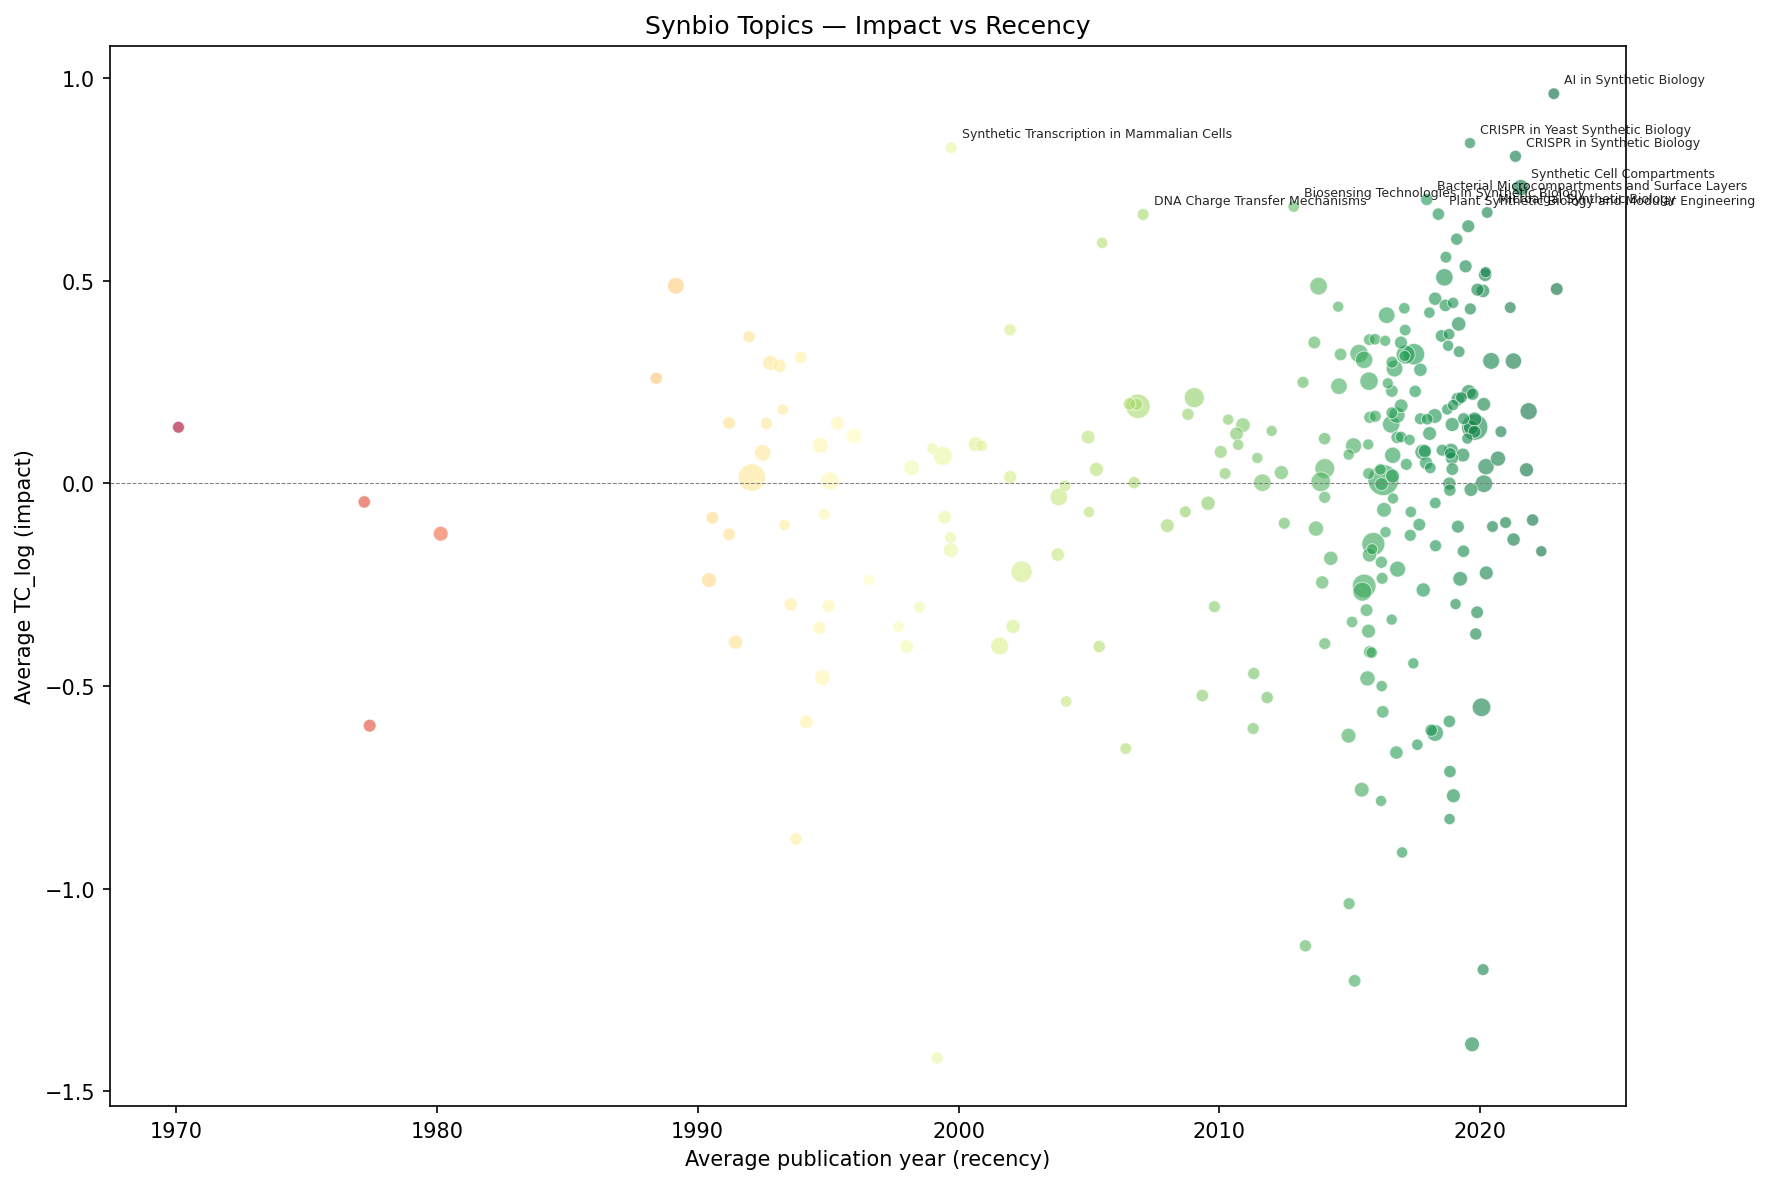

In [5]:
fig, ax = plt.subplots(figsize=(12, 8), dpi=150)

sizes = 20 + 200 * (cluster_summary['n_papers'] / cluster_summary['n_papers'].max())

ax.scatter(
    cluster_summary['avg_year'],
    cluster_summary['avg_TC_log'],
    s=sizes,
    alpha=0.6,
    edgecolors='white',
    linewidth=0.5,
    c=cluster_summary['avg_year'],
    cmap='RdYlGn',
)

top_n = 10
for idx in cluster_summary.nlargest(top_n, 'avg_TC_log').index:
    row = cluster_summary.loc[idx]
    ax.annotate(
        row['global_name'],
        (row['avg_year'], row['avg_TC_log']),
        fontsize=6, alpha=0.85,
        textcoords='offset points', xytext=(5, 5),
    )

ax.set_xlabel('Average publication year (recency)')
ax.set_ylabel('Average TC_log (impact)')
ax.set_title('Synbio Topics — Impact vs Recency')
ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
plt.tight_layout()
plt.show()

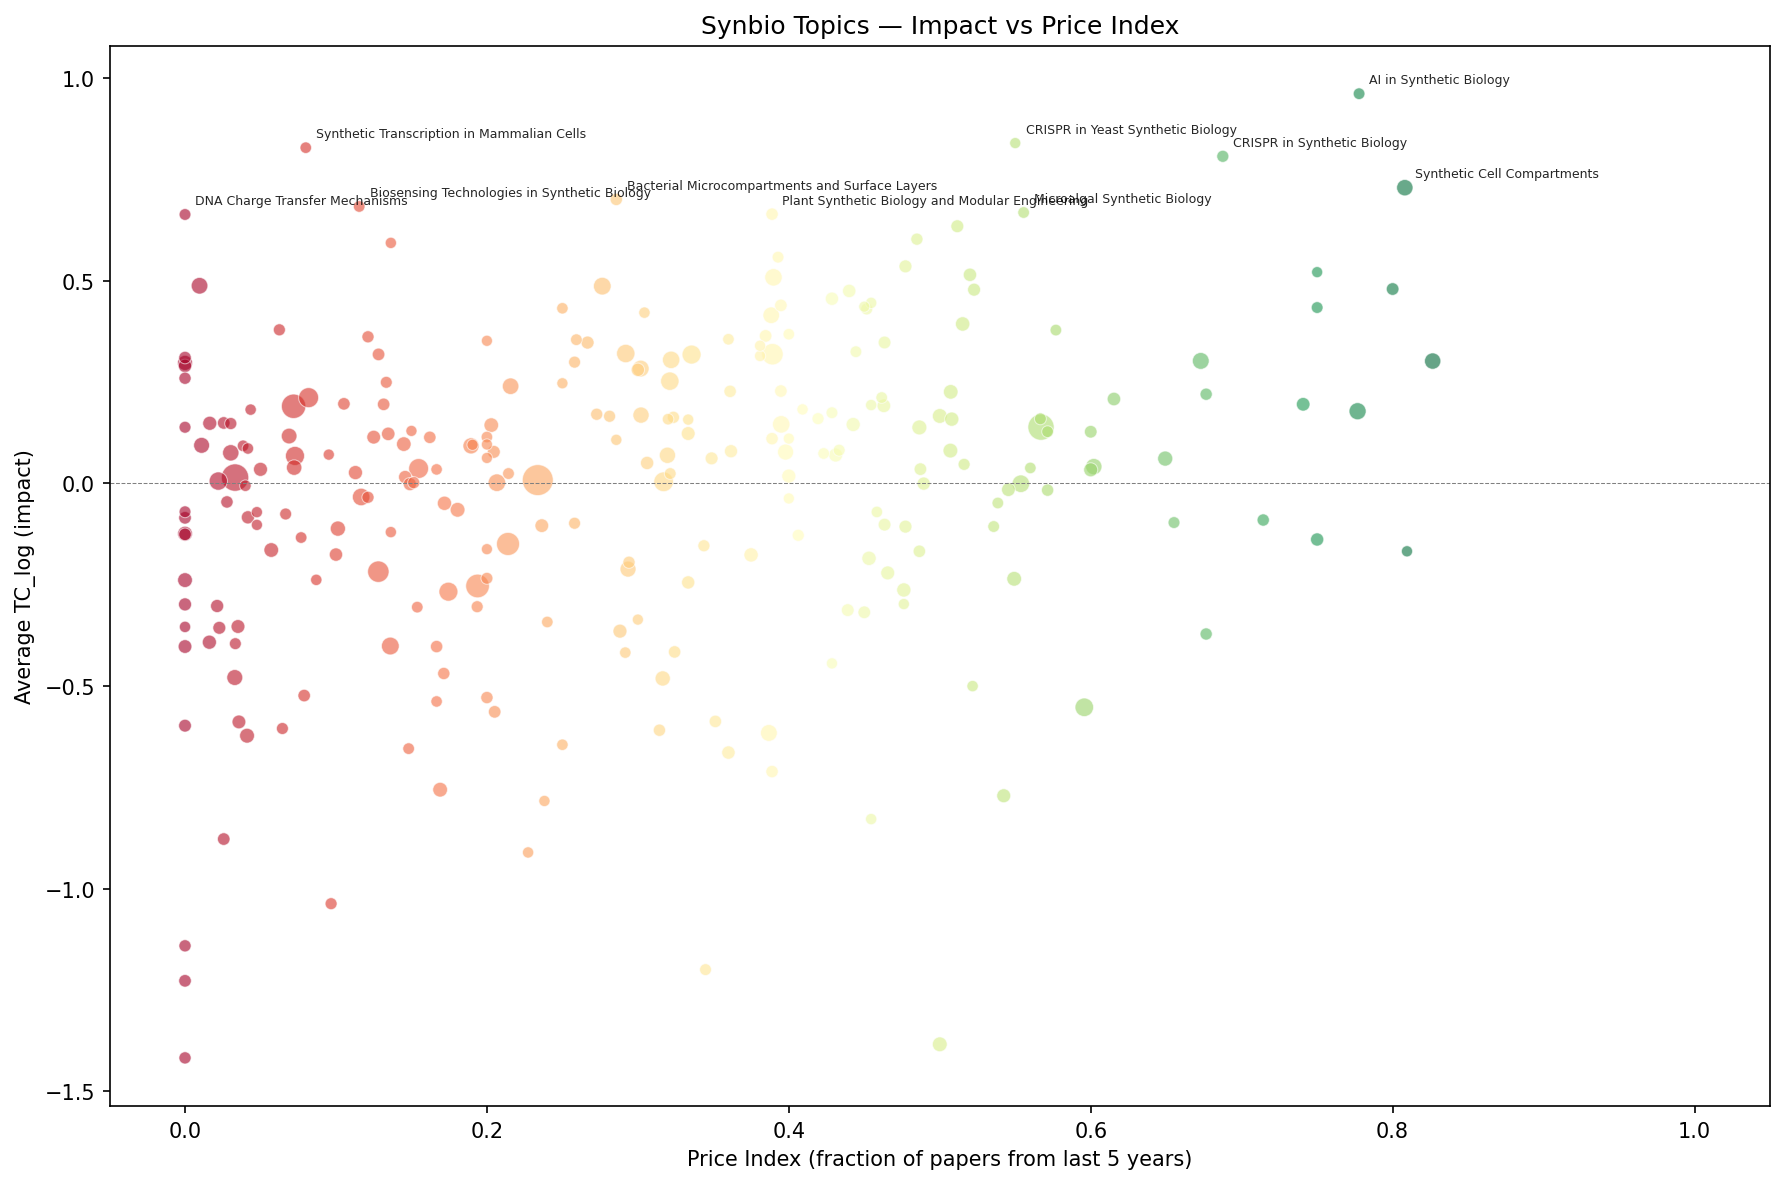

In [6]:
fig, ax = plt.subplots(figsize=(12, 8), dpi=150)

sizes = 20 + 200 * (cluster_summary['n_papers'] / cluster_summary['n_papers'].max())

ax.scatter(
    cluster_summary['price_index'],
    cluster_summary['avg_TC_log'],
    s=sizes,
    alpha=0.6,
    edgecolors='white',
    linewidth=0.5,
    c=cluster_summary['price_index'],
    cmap='RdYlGn',
)

top_n = 10
for idx in cluster_summary.nlargest(top_n, 'avg_TC_log').index:
    row = cluster_summary.loc[idx]
    ax.annotate(
        row['global_name'],
        (row['price_index'], row['avg_TC_log']),
        fontsize=6, alpha=0.85,
        textcoords='offset points', xytext=(5, 5),
    )

ax.set_xlabel('Price Index (fraction of papers from last 5 years)')
ax.set_ylabel('Average TC_log (impact)')
ax.set_title('Synbio Topics — Impact vs Price Index')
ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.set_xlim(-0.05, 1.05)
plt.tight_layout()
plt.show()